# Halo mass function from the FLAMINGO catalogue

We measure the differential halo mass function $f(M)=dn/d\log_{10}M$ (comoving number density per dex) directly from the FLAMINGO L2p8_m9 lightcone catalogue, in **two mass conventions**: $M_{500c}$ and $M_{200c}$.

The catalogue is a full-sky lightcone. In a redshift shell $[z_1, z_2]$ the comoving volume is
$$V = \frac{4\pi}{3}\left[D_C(z_2)^3 - D_C(z_1)^3\right],\qquad D_C(z)=(1+z)\,D_A(z),$$
with $D_A$ from the D3A cosmology (matches the catalogue `r_comoving_Mpc` to $0.01\%$). For mass bin $i$ of width $\Delta\log_{10}M$ holding $N_i$ haloes,
$$f_i = \frac{N_i}{V\,\Delta\log_{10}M},\qquad \sigma(f_i)=\frac{\sqrt{N_i}}{V\,\Delta\log_{10}M}\ \text{(Poisson)}.$$

This notebook shows **only the catalogue data points**; the theory curve will be added later. Note the catalogue is mass-selected on $M_{500c}>5\times10^{13}\,M_\odot$, so the $M_{200c}$ function is incomplete near its low-mass end (a given $M_{200c}$ can host haloes with $M_{500c}$ below the cut).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})


from flamingo import paths
from flamingo.catalogue import load_catalogue, D3A_COSMOLOGY

df = load_catalogue(paths.HYDRO_CATALOGUE)
print('clusters', len(df), '| z range', round(df['z'].min(), 3), '-', round(df['z'].max(), 3))


clusters 1555542 | z range 0.003 - 2.999


In [2]:
# Redshift shell and log10-mass bins.
Z1, Z2 = 0.2, 0.3
DLOG = 0.15
edges = np.arange(13.6, 15.6 + DLOG, DLOG)
centers = 0.5 * (edges[:-1] + edges[1:])

# Full-sky comoving volume of the shell [Mpc^3].
DC1 = float((1 + Z1) * np.asarray(D3A_COSMOLOGY.angular_diameter_distance(Z1)))
DC2 = float((1 + Z2) * np.asarray(D3A_COSMOLOGY.angular_diameter_distance(Z2)))
V_shell = (4.0 * np.pi / 3.0) * (DC2**3 - DC1**3)

shell = df[(df['z'] >= Z1) & (df['z'] < Z2)]
print(f'shell {Z1}<z<{Z2}: {len(shell)} haloes, V = {V_shell:.3e} Mpc^3')


def hmf_points(masses):
    """dn/dlog10M and Poisson error per bin; returns (M, f, ferr) for N>0 bins."""
    N, _ = np.histogram(np.log10(masses), bins=edges)
    f = N / (V_shell * DLOG)
    ferr = np.sqrt(N) / (V_shell * DLOG)
    ok = N > 0
    return 10.0**centers[ok], f[ok], ferr[ok]


M500, f500, e500 = hmf_points(shell['M_500c_Msun'].values)
M200, f200, e200 = hmf_points(shell['M_200c_Msun'].values)
print('M500c bins:', len(M500), '| M200c bins:', len(M200))

shell 0.2<z<0.3: 60305 haloes, V = 5.249e+09 Mpc^3
M500c bins: 12 | M200c bins: 12


## $f(M)=dn/d\log_{10}M$ from the catalogue, two mass conventions

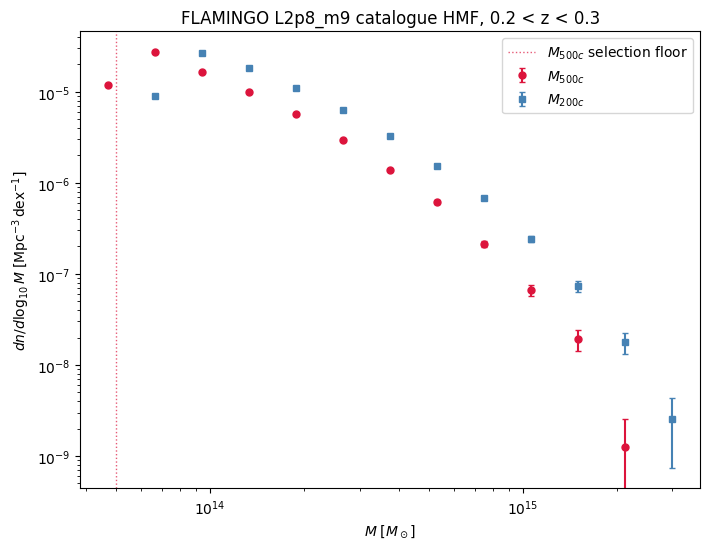

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.errorbar(M500, f500, yerr=e500, fmt='o', ms=5, color='crimson',
            capsize=2, label=r'$M_{500c}$')
ax.errorbar(M200, f200, yerr=e200, fmt='s', ms=5, color='steelblue',
            capsize=2, label=r'$M_{200c}$')
ax.axvline(5e13, color='crimson', ls=':', lw=1, alpha=0.7,
           label=r'$M_{500c}$ selection floor')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M\;[M_\odot]$')
ax.set_ylabel(r'$dn/d\log_{10}M\;[\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$')
ax.set_title(f'FLAMINGO L2p8_m9 catalogue HMF, {Z1} < z < {Z2}')
ax.legend(fontsize=10)
fig.tight_layout(); plt.show()

# HMF ratios to the DMO run

We now compare to the **dark-matter-only (DMO)** FLAMINGO run at $z\simeq0.25$ and form, on one plot:

- $f_{\rm hydro}/f_{\rm DMO}$ for $M_{500c}$ and $M_{200c}$ (the baryonic effect on the HMF);
- $f_{\rm Tinker08}/f_{\rm DMO}$ for $M_{500c}$ (T08 with the $500c$ definition);
- $f_{\rm MiraTitan}/f_{\rm DMO}$ for $M_{200c}$ (Mira-Titan emulator, natively $200c$).

DMO is the periodic SOAP-HBT snapshot at $z=0.25$ (snap 73), box $V=(2800\,\mathrm{Mpc})^3$, with $M_{200c}$ appended from `SO/200_crit/TotalMass` under the same $M_{500c}>5\times10^{13}$ selection. Hydro is the $0.2<z<0.3$ lightcone shell; theory is at $z=0.25$. The shared $M_{500c}$ selection cancels in $f_{\rm hydro}/f_{\rm DMO}(M_{200c})$ but not in $f_{\rm MiraTitan}/f_{\rm DMO}$, so the $M_{200c}$ curves start at the completeness floor (dashed line).

In [4]:
# --- Ratios to the dark-matter-only (DMO) run, at z = 0.25 ---
import pandas as pd
import jax.numpy as jnp
from hmfast.halos import HaloModel, MassDefinition
from hmfast.halos.massfunc import T08HaloMass, MTHaloMass

LN10 = np.log(10.0)
Mc = 10.0**centers
Z_REF = 0.25            # DMO snapshot redshift (snap 73), inside the 0.2<z<0.3 hydro shell

# DMO snapshot catalogue with M200c appended (re-queried from SOAP SO/200_crit
# under the same M500c>5e13 selection, so rows align with the M500c sample).
DMO_M200C = paths.DMO_CATALOGUE.parent / 'halo_catalogue_M500c_5e13_dmo_snaps_M200c.csv'
dmo = pd.read_csv(DMO_M200C, comment='#')
V_box = 2800.0**3       # DMO snapshot box volume [Mpc^3]


def hmf_full(mass, volume):
    """dn/dlog10M and raw counts on the full `edges` grid (aligned with centers)."""
    N, _ = np.histogram(np.log10(mass), bins=edges)
    return N / (volume * DLOG), N


dmo_z = dmo[dmo['snap'] == 73]                       # z = 0.25
fD5, ND5 = hmf_full(dmo_z['M_500c_Msun'].values, V_box)
fD2, ND2 = hmf_full(dmo_z['M_200c_Msun'].values, V_box)
fH5, NH5 = hmf_full(shell['M_500c_Msun'].values, V_shell)   # hydro shell from earlier
fH2, NH2 = hmf_full(shell['M_200c_Msun'].values, V_shell)

# M200c completeness floor: above the 99th-pct M200c of haloes near the M500c cut,
# the M500c>5e13 selection is fully contained. The shared selection cancels in
# f_hydro/f_DMO but not in f_MiraTitan/f_DMO, so M200c curves start here.
near = dmo[(dmo['M_500c_Msun'] > 5e13) & (dmo['M_500c_Msun'] < 5.3e13)]
M200C_COMPLETE = float(np.percentile(near['M_200c_Msun'], 99))
print('DMO z=0.25 haloes:', len(dmo_z), '| M200c completeness floor = %.2e Msun' % M200C_COMPLETE)

DMO z=0.25 haloes: 283013 | M200c completeness floor = 1.07e+14 Msun


In [5]:
# Theory at z = Z_REF: Tinker08 in M500c, Mira-Titan in M200c.
hm500 = HaloModel(cosmology=D3A_COSMOLOGY,
                  mass_definition=MassDefinition(500, 'critical'),
                  halo_mass_function=T08HaloMass())
mt = MTHaloMass(); mt.prepare(D3A_COSMOLOGY)
hm200 = HaloModel(cosmology=D3A_COSMOLOGY,
                  mass_definition=MassDefinition(200, 'critical'),
                  halo_mass_function=mt)

z_ref = jnp.array([Z_REF])
fT5 = LN10 * np.asarray(hm500.halo_mass_function.halo_mass_function(hm500, jnp.asarray(Mc), z_ref))[:, 0]
fMT = LN10 * np.asarray(hm200.halo_mass_function.halo_mass_function(hm200, jnp.asarray(Mc), z_ref))[:, 0]


def ratio(fnum, fden, Nnum, Nden, mmin=0.0):
    """Ratio f_num/f_den with combined Poisson error, for complete, populated bins."""
    ok = (Nden > 0) & (Nnum > 0) & (Mc > mmin)
    r = fnum[ok] / fden[ok]
    rel = np.sqrt(1.0 / Nnum[ok] + 1.0 / Nden[ok])   # data/data
    return Mc[ok], r, r * rel


def ratio_theory(fth, fden, Nden, mmin=0.0):
    """Theory/DMO ratio; error from the DMO Poisson term only."""
    ok = (Nden > 0) & (Mc > mmin)
    r = fth[ok] / fden[ok]
    return Mc[ok], r, r / np.sqrt(Nden[ok])


# M500c samples are complete above the 5e13 selection floor; drop the bin that
# straddles it so the ratios are not biased by selection incompleteness there.
m_h5, r_h5, e_h5 = ratio(fH5, fD5, NH5, ND5, mmin=5e13)
m_h2, r_h2, e_h2 = ratio(fH2, fD2, NH2, ND2, mmin=M200C_COMPLETE)
m_t5, r_t5, e_t5 = ratio_theory(fT5, fD5, ND5, mmin=5e13)
m_mt, r_mt, e_mt = ratio_theory(fMT, fD2, ND2, mmin=M200C_COMPLETE)

## $f/f_{\rm DMO}$ vs mass, two conventions

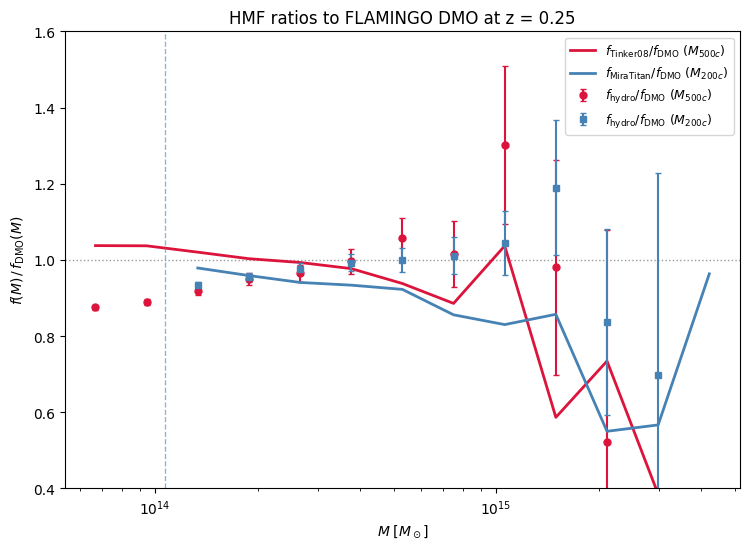

In [6]:
fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.axhline(1.0, color='0.6', lw=1, ls=':')

# M500c (crimson)
ax.errorbar(m_h5, r_h5, yerr=e_h5, fmt='o', ms=5, color='crimson', capsize=2,
            label=r'$f_{\rm hydro}/f_{\rm DMO}$ ($M_{500c}$)')
ax.plot(m_t5, r_t5, '-', lw=2, color='crimson',
        label=r'$f_{\rm Tinker08}/f_{\rm DMO}$ ($M_{500c}$)')

# M200c (steelblue)
ax.errorbar(m_h2, r_h2, yerr=e_h2, fmt='s', ms=5, color='steelblue', capsize=2,
            label=r'$f_{\rm hydro}/f_{\rm DMO}$ ($M_{200c}$)')
ax.plot(m_mt, r_mt, '-', lw=2, color='steelblue',
        label=r'$f_{\rm MiraTitan}/f_{\rm DMO}$ ($M_{200c}$)')

ax.axvline(M200C_COMPLETE, color='steelblue', ls='--', lw=1, alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel(r'$M\;[M_\odot]$')
ax.set_ylabel(r'$f(M)\,/\,f_{\rm DMO}(M)$')
ax.set_ylim(0.4, 1.6)
ax.set_title(f'HMF ratios to FLAMINGO DMO at z = {Z_REF}')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()